In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="ERROR", progress=True)

repository = scarf.cytebase.connect("scarf_docs")
ctrl_path = repository.download_dataset(
    name="kang_15K_pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
stim_path = repository.download_dataset(
    name="kang_14K_ifnb-pbmc_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)

ds_ctrl = scarf.DataStore(f"{ctrl_path}/data.zarr", nthreads=4)
ds_stim = scarf.DataStore(f"{stim_path}/data.zarr", nthreads=4)

Downloading bucket files: 46941374 / 46941374 complete

Downloading bytes: 46941374 / 46941374 complete

Downloading bucket files: 53937553 / 53937553 complete

Downloading bytes: 53937553 / 53937553 complete

In [2]:
ctrl_ids = set(ds_ctrl.RNA.feats.fetch_all("ids").astype(str))
stim_ids = set(ds_stim.RNA.feats.fetch_all("ids").astype(str))

pd.DataFrame(
    [
        {
            "source": label,
            "assay": type(store.RNA).__name__,
            "cells": store.cells.N,
            "active cells": int(store.cells.fetch_all("I").sum()),
            "features": store.RNA.feats.N,
        }
        for label, store in (("ctrl", ds_ctrl), ("stim", ds_stim))
    ]
).assign(shared_features=len(ctrl_ids & stim_ids))

,source,assay,cells,active cells,features,shared_features
0,ctrl,RNAassay,8487,8486,35635,35635
1,stim,RNAassay,10111,10111,35635,35635


In [3]:
merged_path = "scarf_datasets/kang_dataset_merging.zarr"
scarf.DataStoreMerge(
    datasets=[ds_ctrl, ds_stim],
    zarr_path=merged_path,
    names=["ctrl", "stim"],
    assays=["RNA"],
    prepend_text="orig",
    reset_cell_filter=False,
    source_column="sample_id",
    overwrite=True,
).dump()

ds = scarf.DataStore(merged_path, nthreads=4)

Writing merged assay RNA: 27 / 27 complete

Computing RNA initialization statistics: 3 / 3 complete

In [4]:
orig_cols = [
    column
    for column in ds.cells.columns
    if column == "sample_id" or column.startswith("orig_")
]
ds.cells.to_pandas_dataframe(orig_cols, key="I").head()

,sample_id,orig_RNA_UMAP1,orig_RNA_UMAP2,orig_RNA_clusters,orig_RNA_leiden_cluster,orig_RNA_nCounts,orig_RNA_nFeatures,orig_RNA_percentMito,orig_RNA_percentRibo,orig_cluster_labels
0,stim,-14.707423,19.978498,6,6,1070.0,487.0,0.467290,21.588785,CD8 T
1,stim,18.291397,3.745917,3,3,3408.0,897.0,0.117371,9.712441,CD16 Mono
2,stim,-20.303371,-13.024440,7,7,1316.0,543.0,0.075988,42.021277,CD4 naive T
3,stim,-22.439753,8.069315,13,13,1762.0,672.0,0.113507,30.874007,Mk
4,stim,-10.296460,8.768146,2,2,1638.0,653.0,0.366300,18.009768,CD4 Memory T


In [5]:
active_cells = ds.cells.to_pandas_dataframe(
    ["sample_id", "orig_cluster_labels"],
    key="I",
)
active_cells.groupby("sample_id")["orig_cluster_labels"].agg(
    cells="count",
    cell_types="nunique",
)

,cells,cell_types
sample_id,,
ctrl,8486,13
stim,10111,13


In [6]:
baseline = ds.pipeline.run(
    filtering=False,
    cell_cycle_scoring=False,
    highly_variable_features={
        "min_cells": 10,
        "top_n": 2000,
        "min_mean": -3,
        "max_mean": 2,
        "max_var": 6,
    },
    pca={"dims": 25},
    neighbors={"k": 21},
    umap={
        "n_epochs": 250,
        "spread": 5,
        "min_dist": 1,
        "parallel": True,
    },
    leiden={1.0: {"label": "integration_clusters"}},
    paris=False,
    doublet_scoring=False,
    markers=False,
)
sorted(baseline)

Calculating feature statistics: 33 / 33 complete

Writing data: 2 / 2 complete

Fitting PCA: 2 / 2 complete

Writing reduced coordinates: 1 / 1 complete

Calculating reduced coordinates: 2 / 2 complete

Fitting ANN: 1 / 1 complete

Identifying neighbors: 1 / 1 complete

Loading kmeans coordinates: 1 / 1 complete

Training UMAP: 250 / 250 complete

['ann_index',
 'connectivity_map',
 'embedding_initialization',
 'highly_variable_features',
 'leiden_1.0',
 'neighbors',
 'normalized',
 'pca',
 'selected_clusters',
 'umap']

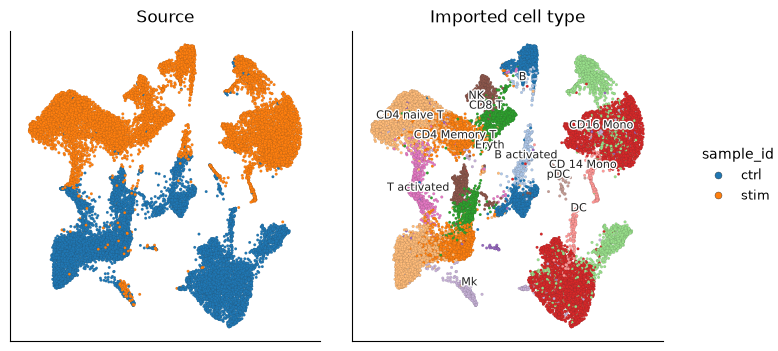

In [7]:
comparison = ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by=["sample_id", "orig_cluster_labels"],
    n_columns=2,
    show_titles=False,
    show=False,
)
for axis, title in zip(
    comparison.axes.values(),
    ("Source", "Imported cell type"),
    strict=True,
):
    axis.set_title(title)
comparison.show()

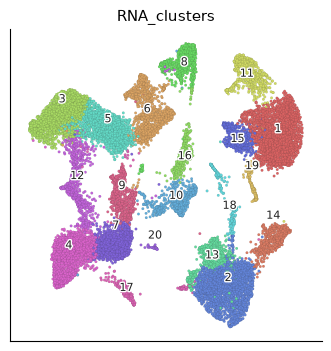

In [8]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="RNA_clusters",
)

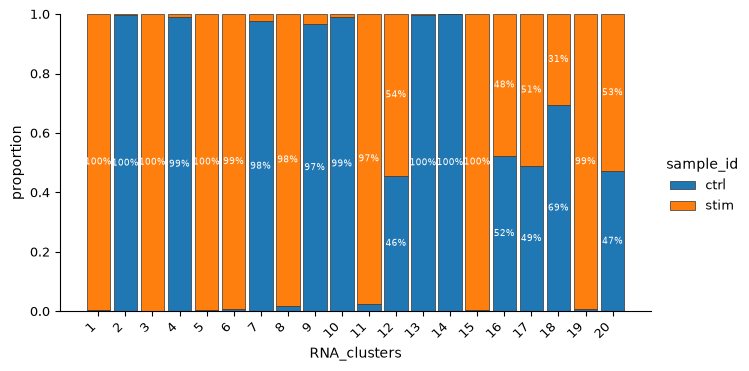

In [9]:
ds.plots.composition(
    category_by="sample_id",
    sample_by="RNA_clusters",
    kind="stacked",
    show_percent_labels=True,
)

In [10]:
uncorrected_ilisi = ds.metric_ilisi(
    batch_colname="sample_id",
    perplexity=7,
)
{"uncorrected iLISI": round(uncorrected_ilisi, 3)}

Computing LISI: 2 / 2 complete

{'uncorrected iLISI': 0.0}

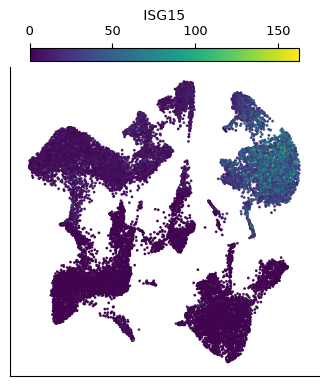

In [11]:
ds.plots.embedding(
    layout_key="RNA_UMAP",
    color_by="ISG15",
)